#Globals

In [ ]:
#!pip install scipy

In [ ]:
import numpy as np
import time
import scipy.constants as consts
import matplotlib.pyplot as plt
import math
import random

In [ ]:
def collect_m_z_state_vecs(basis_vecs):
  N = int(math.log(len(basis_vecs),2))
  all_m_z_bin_state_vecs = [[] for n in range(N+1)]
  all_m_z_state_vecs = [[] for n in range(N+1)]

  binary_basis_vecs = np.array([int_to_binary_array(basis_vec, N) for basis_vec in basis_vecs])

  for i, binary_basis_vec in enumerate(binary_basis_vecs):
    i_m_z = N - np.count_nonzero(binary_basis_vec)
    all_m_z_bin_state_vecs[i_m_z].append(binary_basis_vec)
    all_m_z_state_vecs[i_m_z].append(basis_vecs[i])

  return all_m_z_bin_state_vecs, all_m_z_state_vecs

In [ ]:
def int_to_binary_array(number, fixed_length):
  # print(number)
  binary_string = bin(number)[2:]  # Convert integer to binary and remove the '0b' prefix
  binary_list = [int(bit) for bit in binary_string.zfill(fixed_length)]
  return np.array(binary_list)

In [ ]:
def flip(N, a, i, j):
  mask = np.zeros(N)
  mask[i] = int(1)
  mask[j] = int(1)
  # print(f'mask: {mask}')

  return int(np.char.array(a ^ mask.astype(int)).tobytes().decode('utf-8'), 2)

In [ ]:
def construct_H(N):
  basis_vecs = [i for i in range(2**N)]
  H = np.zeros((2**N,2**N))
  # print(basis_vecs)
  for int_a in basis_vecs:
    # print(int_a)
    a = int_to_binary_array(int_a, N)
    # print(a)
    for i in range(N):
      j = (i+1) % N
      # print(i,j)
      if a[i] == a[j]:
        H[int_a][int_a] += 1/4
      else:
        H[int_a][int_a] += -1/4
        int_b = flip(N, a, i, j)
        H[int_a][int_b] = 1/2

      # print('-----------------------------------------------------------------')

  return H, np.array(basis_vecs)

In [ ]:
N2 = 2
H2, basis_vecs_2 = construct_H(N2)

N3 = 3
H3, basis_vecs_3 = construct_H(N3)

N4 = 4
H4, basis_vecs_4 = construct_H(N4)

N5 = 5
H5, basis_vecs_5 = construct_H(N5)

N6 = 6
H6, basis_vecs_6 = construct_H(N6)

In [ ]:
H6_12 = []
basis_vecs_6_12 = []
for i in range(6,13):
  H, state_vec = construct_H(i)
  H6_12.append(H)
  basis_vecs_6_12.append(state_vec)

In [ ]:
def find_i_b(block_state_vecs, b):
  i_b_min = 0
  i_b_max = len(block_state_vecs)-1
  while True:
    i_b = int((i_b_max + i_b_min)/2)
    # print(f'i_b = {i_b}, b = {b}, block_state_vecs[i_b] = {block_state_vecs[i_b]}')
    if block_state_vecs[i_b] > b:
      i_b_max = i_b - 1
    elif block_state_vecs[i_b] < b:
      i_b_min = i_b + 1
    else:
      break
    # input("Press Enter to continue...")

  return i_b

In [ ]:
def construct_H_block(bin_block_state_vecs, block_state_vecs):
  # print(block_state_vecs)
  N_block = len(bin_block_state_vecs)
  N = len(bin_block_state_vecs[0])
  H_block = np.zeros((N_block,N_block))
  for i_a, a in enumerate(bin_block_state_vecs):
    for i in range(len(a)):
      j = (i+1) % N
      if a[i] == a[j]:
        H_block[i_a][i_a] += 1/4
      else:
        H_block[i_a][i_a] += -1/4
        int_b = flip(N, a, i, j)

        i_b = find_i_b(block_state_vecs, int_b)

        H_block[i_a][i_b] = 1/2


  return H_block

#1. Warm-up

##a

In [ ]:
int('110101',2)

53

##b

In [ ]:
i = -1
diff = 1
a = 9588514242
bin_a = bin(a)[2:]
print(bin(a))
len_bin_a = len(bin_a)
shifted_a = a

while diff != 0:
  i += 1
  # print(i)
  shifted_a = shifted_a >> 1
  extra_bit = int(bin_a[-(i+1)])
  weight = 2**(len_bin_a -1)
  shifted_a += extra_bit*weight
  print(bin(shifted_a))
  diff = a - shifted_a
  # print('---------------------------------------------------------------------')

print()
print(i)

0b1000111011100001010001110111000010
0b100011101110000101000111011100001
0b1010001110111000010100011101110000
0b101000111011100001010001110111000
0b10100011101110000101000111011100
0b1010001110111000010100011101110
0b101000111011100001010001110111
0b1000010100011101110000101000111011
0b1100001010001110111000010100011101
0b1110000101000111011100001010001110
0b111000010100011101110000101000111
0b1011100001010001110111000010100011
0b1101110000101000111011100001010001
0b1110111000010100011101110000101000
0b111011100001010001110111000010100
0b11101110000101000111011100001010
0b1110111000010100011101110000101
0b1000111011100001010001110111000010

16


#2. Direct diagonalisation

##Commons

In [ ]:
def calc_m_z(state, N):
  return np.count_nonzero(state)/N - 0.5

##a

###N = 2

In [ ]:
# print(H2)
eigenvalues_2, eigenvectors_2 = np.linalg.eigh(H2)
print(f'Ground state energy = {min(eigenvalues_2)}')
gnd_state_2 = int_to_binary_array(basis_vecs_2[np.where(eigenvectors_2[np.argmin(eigenvalues_2)] == 1)[0][0]], N2)
print(f'Ground state eigenvector = {gnd_state_2}')
m_z_2 = calc_m_z(gnd_state_2, N2)
print(f'm_z = {m_z_2}')
print(f'Eigenvalues = {eigenvalues_2}')

Ground state energy = -1.0
Ground state eigenvector = [1 0]
m_z = 0.0
Eigenvalues = [-1.   0.   0.5  0.5]


###N = 3

In [ ]:
# print(H3)
eigenvalues_3, eigenvectors_3 = np.linalg.eigh(H3)
print(f'Ground state energy = {min(eigenvalues_3)}')
gnd_state_3 = int_to_binary_array(basis_vecs_3[np.where(eigenvectors_3[np.argmin(eigenvalues_3)] == 1)[0][0]], N3)
print(f'Ground state eigenvector = {gnd_state_3}')
m_z_3 = calc_m_z(gnd_state_3, N3)
print(f'm_z = {m_z_3}')
print(f'Eigenvalues = {eigenvalues_3}')

Ground state energy = -0.7500000000000001
Ground state eigenvector = [1 1 0]
m_z = 0.16666666666666663
Eigenvalues = [-0.75 -0.75 -0.75 -0.75  0.75  0.75  0.75  0.75]


###N = 4

In [ ]:
# print(H4)
eigenvalues_4, eigenvectors_4 = np.linalg.eigh(H4)
print(f'Ground state energy = {min(eigenvalues_4)}')
gnd_state_4 = int_to_binary_array(basis_vecs_4[np.where(eigenvectors_4[np.argmin(eigenvalues_4)] == 1)[0][0]], N4)
print(f'Ground state eigenvector = {gnd_state_4}')
m_z_4 = calc_m_z(gnd_state_4, N4)
print(f'm_z = {m_z_4}')
print(f'Eigenvalues = {eigenvalues_4}')

Ground state energy = -1.9999999999999996
Ground state eigenvector = [1 1 0 1]
m_z = 0.25
Eigenvalues = [-2.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
 -2.25514052e-17 -1.78638187e-17 -7.68015095e-32  0.00000000e+00
  2.42866341e-47  6.17036833e-34  1.31651255e-31  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00]


###N = 5

In [ ]:
# print(H5)
eigenvalues_5, eigenvectors_5 = np.linalg.eigh(H5)
print(f'Ground state energy = {min(eigenvalues_5)}')
gnd_state_5 = int_to_binary_array(basis_vecs_5[np.where(eigenvectors_5[np.argmin(eigenvalues_5)] == 1)[0][0]], N5)
print(f'Ground state eigenvector = {gnd_state_5}')
m_z_5 = calc_m_z(gnd_state_5, N5)
print(f'm_z = {m_z_5}')
print(f'Eigenvalues = {eigenvalues_5}')

Ground state energy = -1.868033988749896
Ground state eigenvector = [1 1 0 1 0]
m_z = 0.09999999999999998
Eigenvalues = [-1.86803399 -1.86803399 -1.86803399 -1.86803399 -0.75       -0.75
 -0.55901699 -0.55901699 -0.55901699 -0.55901699 -0.55901699 -0.55901699
 -0.55901699 -0.55901699  0.36803399  0.36803399  0.36803399  0.36803399
  0.55901699  0.55901699  0.55901699  0.55901699  0.55901699  0.55901699
  0.55901699  0.55901699  1.25        1.25        1.25        1.25
  1.25        1.25      ]


###N = 6

In [ ]:
# print(H6)
eigenvalues_6, eigenvectors_6 = np.linalg.eigh(H6)
print(f'Ground state energy = {min(eigenvalues_6)}')
gnd_state_6 = int_to_binary_array(basis_vecs_6[np.where(eigenvectors_6[np.argmin(eigenvalues_6)] == 1)[0][0]], N6)
print(f'Ground state eigenvector = {gnd_state_6}')
m_z_6 = calc_m_z(gnd_state_6, N6)
print(f'm_z = {m_z_6}')
print(f'Eigenvalues = {eigenvalues_6}')

Ground state energy = -2.802775637731995
Ground state eigenvector = [1 1 1 1 0 0]
m_z = 0.16666666666666663
Eigenvalues = [-2.80277564e+00 -2.11803399e+00 -2.11803399e+00 -2.11803399e+00
 -1.50000000e+00 -1.28077641e+00 -1.28077641e+00 -1.28077641e+00
 -1.28077641e+00 -1.28077641e+00 -1.28077641e+00 -1.00000000e+00
 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00 -1.00000000e+00
 -1.00000000e+00 -5.00000000e-01 -5.00000000e-01 -5.00000000e-01
 -5.00000000e-01 -5.00000000e-01 -5.00000000e-01 -5.00000000e-01
 -5.91279279e-16 -1.73709828e-16 -1.72533340e-16  3.27070636e-17
  1.32810875e-16  1.57555114e-16  1.80356046e-16  2.42926763e-16
  3.37788617e-16  4.76862657e-16  1.18033989e-01  1.18033989e-01
  1.18033989e-01  5.00000000e-01  5.00000000e-01  5.00000000e-01
  7.80776406e-01  7.80776406e-01  7.80776406e-01  7.80776406e-01
  7.80776406e-01  7.80776406e-01  8.02775638e-01  1.00000000e+00
  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
  1.00000000e+00  1.00000000e+00 

##b

In [ ]:
def calc_diag_time(H):
  start_time = time.time()
  result = np.linalg.eigh(H)
  end_time = time.time()
  return end_time - start_time

For N = 2, t = 0.000106
For N = 3, t = 0.004165
For N = 4, t = 0.000627
For N = 5, t = 0.000592
For N = 6, t = 0.001128
For N = 7, t = 0.005522
For N = 8, t = 0.009876
For N = 9, t = 0.054621
For N = 10, t = 0.334627
For N = 11, t = 2.460207
For N = 12, t = 21.894810


Text(0, 0.5, 'Direct Diagonalisation Time (s)')

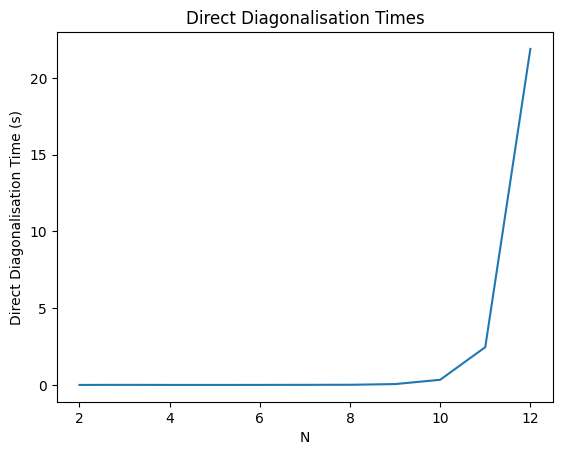

In [ ]:
H2_5 = [H2, H3, H4, H5]
diag_times = []
Ns = [n for n in range(2,13)]

for i, H in enumerate(H2_5 + H6_12):
  diag_time = calc_diag_time(H)
  print(f'For N = {i+2}, t = {diag_time:.6f}')
  diag_times.append(diag_time)

plt.plot(Ns, diag_times)
plt.title('Direct Diagonalisation Times')
plt.xlabel('N')
plt.ylabel('Direct Diagonalisation Time (s)')

##c

###Commons

In [ ]:
def calc_Z(H_eigenvalues, T):
  return np.sum(np.exp(-H_eigenvalues/(T)))

In [ ]:
def calc_E_var(Z, H_eigenvalues, T):
  var = np.sum(np.square(H_eigenvalues)*np.exp(-H_eigenvalues/(T)))/Z - (np.sum(H_eigenvalues*np.exp(-H_eigenvalues/(T)))/Z)**2
  return var

In [ ]:
N = [4,8,12]
T = np.linspace(0.1,2)
all_H_eigenvalues = []
all_H_eigenvectors = []
H8 = H6_12[2]
basis_vecs_8 = basis_vecs_6_12[2]
basis_vecs_12 = basis_vecs_6_12[-1]
H12 = H6_12[-1]
for H in [
    H2,
    H4,
    H8,
    H12
]:
  H_eigenvalues, H_eigenvectors = np.linalg.eigh(H)
  all_H_eigenvalues.append(H_eigenvalues)
  all_H_eigenvectors.append(H_eigenvectors)

###C

In [ ]:
def calc_C(H_eigenvalues, T):
  N = math.log(len(H_eigenvalues), 2)
  # print(f'N = {N}')
  Z = calc_Z(H_eigenvalues, T)
  E_var = calc_E_var(Z, H_eigenvalues, T)
  return E_var/T**2/N

In [ ]:
C_N = []
for i, E in enumerate(all_H_eigenvalues):
  C_N.append([calc_C(E, t) for t in T])

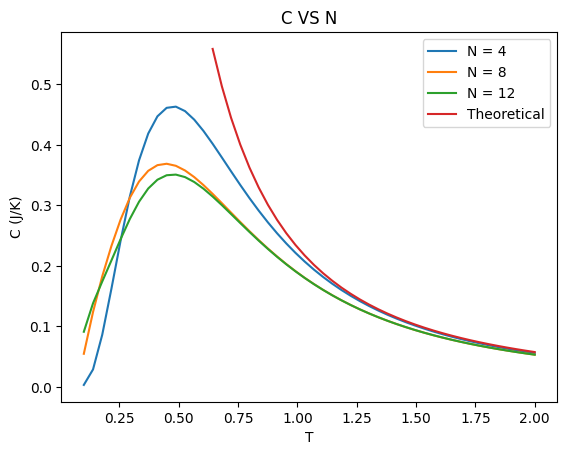

In [ ]:
plt.plot(T, C_N[0], label='N = 4')
plt.plot(T, C_N[1], label='N = 8')
plt.plot(T, C_N[2], label='N = 12')
plt.plot(T[14:], 3/13/T[14:]**2, label='Theoretical')
# plt.ylim(0,0.12)

plt.title(f'C VS N')
plt.ylabel('C (J/K)')
plt.xlabel('T')
plt.legend()

###χ

In [ ]:
def calc_X(basis_vecs, H_eigenvalues, H_eigenvectors, T):
  N = int(math.log(len(basis_vecs), 2))
  binary_basis_vecs = np.array([int_to_binary_array(np.array(basis_vec), N) for basis_vec in basis_vecs])
  basis_vecs_m_z = [calc_m_z(binary_basis_vec, N) for binary_basis_vec in binary_basis_vecs]

  X = []

  for t in T:
    M = []
    M_sq = []
    Z = calc_Z(H_eigenvalues, t)
    for e, H_eigenvector in enumerate(H_eigenvectors):
      m_z_evec = 0
      m_z_evec_sq = 0
      for i, c in enumerate(H_eigenvector):
        m_z_evec += c**2*basis_vecs_m_z[i]
        m_z_evec_sq += c**2*(basis_vecs_m_z[i])**2
      M.append(m_z_evec*np.exp(-H_eigenvalues[e]/t))
      M_sq.append(m_z_evec_sq*np.exp(-H_eigenvalues[e]/t))

    M = np.array(M)
    M_sq = np.array(M_sq)
    X.append((np.sum(M_sq)/Z - (np.sum(M)/Z)**2)/t)

  return X

In [ ]:
X_N = []
for j, basis_vecs in enumerate(
    [
        basis_vecs_4,
        basis_vecs_8,
        basis_vecs_12
    ]
):
  X_N.append(calc_X(basis_vecs, all_H_eigenvalues[j], all_H_eigenvectors[j], T))

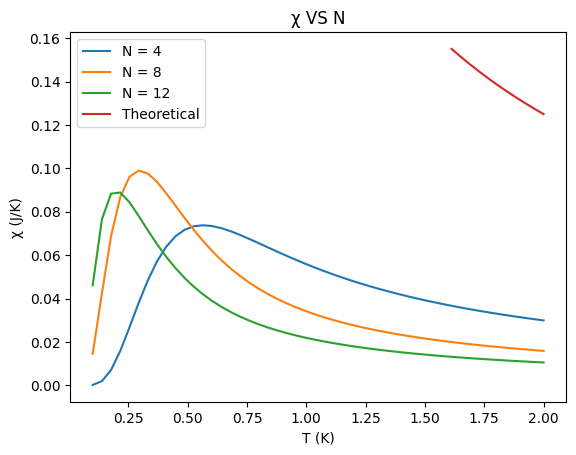

In [ ]:
plt.plot(T, X_N[0], label='N = 4')
plt.plot(T, X_N[1], label='N = 8')
plt.plot(T, X_N[2], label='N = 12')
plt.plot(T[39:], 0.25/T[39:], label='Theoretical')

plt.title(f'χ VS N')
plt.ylabel('χ (J/K)')
plt.xlabel('T (K)')
plt.legend()
# plt.ylim(0, 0.15)

### S_02

In [ ]:
def calc_S02_per_state(state_vec):
  S0 = state_vec[0]
  # S2 = state_vec[2]
  S2 = state_vec[1]
  return ((not S0)*-1 + (S0 and 1))*((not S2)*-1 + (S2 and 1))*0.25

In [ ]:
def calc_S02(H_eigenvectors, H_eigenvalues, basis_vecs, T):
  N = int(math.log(len(basis_vecs), 2))
  # print(f'Basis vecs in calc_S02: {basis_vecs}')
  binary_basis_vecs = np.array([int_to_binary_array(np.array(basis_vec), N) for basis_vec in basis_vecs])
  basis_vecs_S02 = [calc_S02_per_state(binary_basis_vec) for binary_basis_vec in binary_basis_vecs]
  # print(binary_basis_vecs)
  # print(basis_vecs_S02)

  S02 = []

  for t in T:
    S02_t = []
    Z = calc_Z(H_eigenvalues, t)
    for e, H_eigenvector in enumerate(H_eigenvectors):

      # S02 per eigenvector
      S02_e = 0
      for i, c in enumerate(H_eigenvector):
        S02_e += c**2*basis_vecs_S02[i]

      S02_e = S02_e*np.exp(-H_eigenvalues[e]/t)

    S02.append(np.sum(S02_e)/Z)
    # print(np.sum(S02))

  return S02

In [ ]:
S02_N = []
for j, basis_vecs in enumerate(
    [
        basis_vecs_2,
        basis_vecs_4,
        basis_vecs_8,
        basis_vecs_12
    ]
):
  S02_N.append(calc_S02(all_H_eigenvectors[j], all_H_eigenvalues[j], basis_vecs, T))

Text(0.5, 0, 'T')

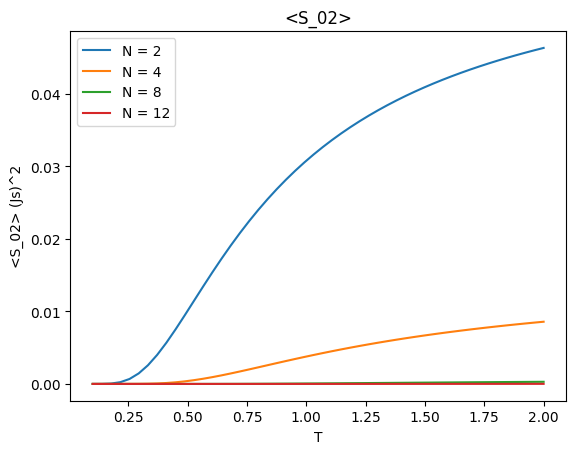

In [ ]:
plt.plot(T, S02_N[0], label='N = 2')
# plt.plot(T, S02_N[0], label='N = 4')
plt.plot(T, S02_N[1], label='N = 4')
# plt.plot(T, S02_N[1], label='N = 8')
plt.plot(T, S02_N[2], label='N = 8')
# plt.plot(T, S02_N[2], label='N = 12')
plt.plot(T, S02_N[3], label='N = 12')
plt.legend()

plt.title(f'<S_02>')
plt.ylabel('<S_02> (Js)^2')
plt.xlabel('T')
# plt.ylim(0,0.00025)

#3. Block-diagonalisation into mz subspaces

In [ ]:
block_diagonalisation_times = []
Ns = [n for n in range(2,13)]

for n, basis_vecs in enumerate([basis_vecs_2, basis_vecs_3, basis_vecs_4, basis_vecs_5] + basis_vecs_6_12):
  # print(basis_vecs)
  all_m_z_bin_state_vecs, all_m_z_state_vecs = collect_m_z_state_vecs(basis_vecs)
  # print(all_m_z_state_vecs)

  H_blocks = []
  for j_m_z, m_z_bin_state_vecs in enumerate(all_m_z_bin_state_vecs):
    H_block = construct_H_block(m_z_bin_state_vecs, all_m_z_state_vecs[j_m_z])
    # print(H_block)
    H_blocks.append(H_block)

  eigenvalues_blocked = []
  start_time = time.time()
  for i_block, H_block in enumerate(H_blocks):
    block_eigenvalues, block_eigenvectors = np.linalg.eigh(H_block)
    eigenvalues_blocked.extend(block_eigenvalues.tolist())
  end_time = time.time()
  block_diagonalisation_time = end_time - start_time
  print(f'Diagonalisation time for N = {n+2} = {block_diagonalisation_time}')
  block_diagonalisation_times.append(block_diagonalisation_time)


  # print(eigenvalues_blocked)
  print(eigenvalues_blocked)
  print(f'Gnd-state energy for N = {n+2} = {min(eigenvalues_blocked)}')
  print('---------------------------------------------------------------------')

Diagonalisation time for N = 2 = 0.014702796936035156
[0.5, -1.0, 0.0, 0.5]
Gnd-state energy for N = 2 = -1.0
---------------------------------------------------------------------
Diagonalisation time for N = 3 = 0.005029201507568359
[0.75, -0.7500000000000001, -0.7499999999999998, 0.7499999999999999, -0.7500000000000001, -0.7499999999999998, 0.7499999999999999, 0.75]
Gnd-state energy for N = 3 = -0.7500000000000001
---------------------------------------------------------------------
Diagonalisation time for N = 4 = 0.0011463165283203125
[1.0, -1.0, -2.2551405187698492e-17, 0.0, 1.0, -1.9999999999999996, -0.9999999999999999, -6.199084105705142e-17, 0.0, 6.842277657836021e-49, 0.9999999999999999, -1.0, -2.2551405187698492e-17, 0.0, 1.0, 1.0]
Gnd-state energy for N = 4 = -1.9999999999999996
---------------------------------------------------------------------
Diagonalisation time for N = 5 = 0.0001819133758544922
[1.25, -0.5590169943749476, -0.559016994374947, 0.5590169943749472, 0.5590

Text(0.5, 1.0, 'Total Bloack Diagonalisation Time VS N')

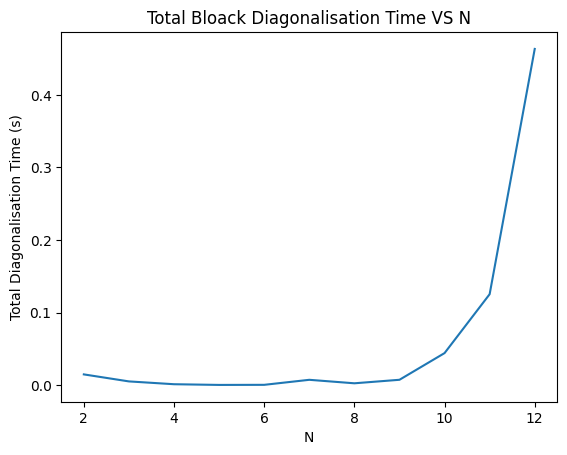

In [ ]:
# plt.plot(Ns,block_diagonalisation_times, label='Block diagonalisation')
plt.plot(Ns,block_diagonalisation_times)
# plt.plot(Ns, diag_times, label='Direct diagonalisation')
plt.ylabel('Total Diagonalisation Time (s)')
plt.xlabel('N')
# plt.title('Total Diagonalisation Time VS N')
plt.title('Total Bloack Diagonalisation Time VS N')
# plt.legend()

#4. Lanczos method

##Commons

In [ ]:
def construct_tri_d_H(N, all_a, all_b):
  tri_d_H = np.zeros((N,N))

  tri_d_H[0][0] = all_a[0]
  if N > 1:
    tri_d_H[1][0] = np.sqrt(all_b[0])
    for l in range(1,N-1):
      tri_d_H[l-1][l] = np.sqrt(all_b[l-1])
      tri_d_H[l][l] = all_a[l]
      tri_d_H[l+1][l] = np.sqrt(all_b[l])
    tri_d_H[N-1][N-1] = all_a[N-1]
    tri_d_H[N-2][N-1] = np.sqrt(all_b[N-2])

  return tri_d_H

In [ ]:
def calc_min_E(basis_vecs):
  start = 0
  all_m_z_bin_state_vecs, all_m_z_state_vecs = collect_m_z_state_vecs(basis_vecs)
  all_E = []

  for j_m_z, m_z_bin_state_vecs in enumerate(all_m_z_bin_state_vecs[start:]):
    all_f = []
    all_f_norms = []
    # print(m_z_bin_state_vecs)
    print(len(m_z_bin_state_vecs))
    M = len(m_z_bin_state_vecs)

    # f_0
    c = (np.random.randn(M))
    f = c
    all_f.append(f)
    norm_f = np.linalg.norm(f)
    all_f_norms.append(norm_f)

    H_block = construct_H_block(m_z_bin_state_vecs, all_m_z_state_vecs[j_m_z+start])
    # print(H_block)

    all_a = []
    all_b = []

    H_f = np.dot(H_block,f)
    norm_f = np.linalg.norm(f)

    # a0
    a = np.dot(f, H_f)/norm_f**2
    all_a.append(a)

    tri_d_H = construct_tri_d_H(1, all_a, all_b)
    # print(f'Tri-D H:')
    # print(tri_d_H)
    # print(f'all_a = {all_a}')
    # print(f'all_b = {all_b}')

    tri_d_H_evals, tri_d_H_evecs = np.linalg.eigh(tri_d_H)
    all_E.extend(tri_d_H_evals)
    # print(f'all_E = {all_E}')
    min_E = min(all_E)
    # print(f'Min(E) = {min_E}')

    #f1
    f = H_f - a*f
    # print(f'<f_m|f_m-1> = {np.dot(f, all_f[-1])}')
    norm_f = np.linalg.norm(f)

    all_f.append(f)
    all_f_norms.append(norm_f)

    # print('Entering the M loop...')
    for L in range(1,M):
      H_f = np.dot(H_block,f)
      # a1+
      a = np.dot(f, H_f)/norm_f**2
      all_a.append(a)
      # b0+
      b = (norm_f/all_f_norms[-2])**2
      all_b.append(b)

      tri_d_H = construct_tri_d_H(L+1, all_a, all_b)
      # print(f'Tri-D H:')
      # print(tri_d_H)
      # print(f'all_a = {all_a}')
      # print(f'all_b = {all_b}')

      tri_d_H_evals, tri_d_H_evecs = np.linalg.eigh(tri_d_H)
      # print(f'all_E = {all_E}')
      new_min_E = min(tri_d_H_evals)
      print(f'new_min_E = {new_min_E}')

      if (L > 1):
        print(f'min_E_L = {min_E_L}')
        if abs(new_min_E - min_E_L) < 1e-6:
          print(f'CONVERGENCE CONDITION EXIT: New E_min = {new_min_E}, E_min = {min_E_L}')
          break
        min_E_L = min(min_E_L, new_min_E)
      else:
        min_E_L = new_min_E


      # f2+
      f = H_f - a*f - b*all_f[-2]
      # print(f'<f_m|f_m-1> = {np.dot(f, all_f[-1])}')
      # print(f'<f_m|f_m-2> = {np.dot(f, all_f[-2])}')
      norm_f = np.linalg.norm(f)

      all_f.append(f)
      all_f_norms.append(norm_f)

      H_f = np.dot(H_block, f)
      norm_f = np.linalg.norm(f)

    # print('Exited the M loop...')
    all_E.extend(tri_d_H_evals)
    print('---------------------------------------------------------------------')
  return min_E

##a

In [ ]:
Lanczos_times = []
min_Es = []
Ns = [n for n in range(2,13)]

for n, basis_vecs in enumerate([basis_vecs_2, basis_vecs_3, basis_vecs_4, basis_vecs_5] + basis_vecs_6_12):
  start_time = time.time()
  min_E = calc_min_E(basis_vecs)
  end_time = time.time()
  min_Es.append(min_E)
  Lanczos_time = end_time - start_time
  Lanczos_times.append(Lanczos_time)

1
---------------------------------------------------------------------
2
new_min_E = -1.0
---------------------------------------------------------------------
1
---------------------------------------------------------------------
1
---------------------------------------------------------------------
3
new_min_E = -0.7499999999999998
new_min_E = -0.7499999999999999
min_E_L = -0.7499999999999998
CONVERGENCE CONDITION EXIT: New E_min = -0.7499999999999999, E_min = -0.7499999999999998
---------------------------------------------------------------------
3
new_min_E = -0.7500000000000002
new_min_E = -0.7500000000000002
min_E_L = -0.7500000000000002
CONVERGENCE CONDITION EXIT: New E_min = -0.7500000000000002, E_min = -0.7500000000000002
---------------------------------------------------------------------
1
---------------------------------------------------------------------
1
---------------------------------------------------------------------
4
new_min_E = -0.9996192859718094
new_min

In [ ]:
for n in Ns:
  print(f'Gnd-state energy for N = {n} = {min_Es[n-2]}')
  print(f'Lanczos time for N = {n} = {Lanczos_times[n-2]}')

Gnd-state energy for N = 2 = -1.0
Lanczos time for N = 2 = 0.006723880767822266
Gnd-state energy for N = 3 = -0.7500000000000002
Lanczos time for N = 3 = 0.000823974609375
Gnd-state energy for N = 4 = -2.0
Lanczos time for N = 4 = 0.014114856719970703
Gnd-state energy for N = 5 = -1.8680339887498951
Lanczos time for N = 5 = 0.026035308837890625
Gnd-state energy for N = 6 = -2.8027756376557313
Lanczos time for N = 6 = 0.04432344436645508
Gnd-state energy for N = 7 = -2.8551792096303035
Lanczos time for N = 7 = 0.06441140174865723
Gnd-state energy for N = 8 = -3.6510932462269254
Lanczos time for N = 8 = 0.09680485725402832
Gnd-state energy for N = 9 = -3.797299723965428
Lanczos time for N = 9 = 0.12335801124572754
Gnd-state energy for N = 10 = -4.515446185677154
Lanczos time for N = 10 = 0.30615997314453125
Gnd-state energy for N = 11 = -4.718936131061461
Lanczos time for N = 11 = 0.48317623138427734
Gnd-state energy for N = 12 = -5.387390799316563
Lanczos time for N = 12 = 1.00883221626

/usr/local/lib/python3.10/dist-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


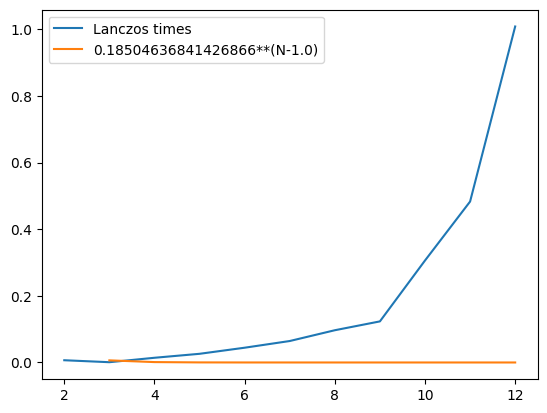

In [ ]:
from scipy.optimize import curve_fit

def del_exp(x, a, b):
  return a**(x)

params, covariance = curve_fit(del_exp, Ns[1:], Lanczos_times[1:])
plt.plot(Ns, Lanczos_times, label='Lanczos times')
a, b = params
plt.plot(Ns[1:], del_exp(Ns[1:], a, b), label=f'{a}**(N-{b})')
plt.legend()

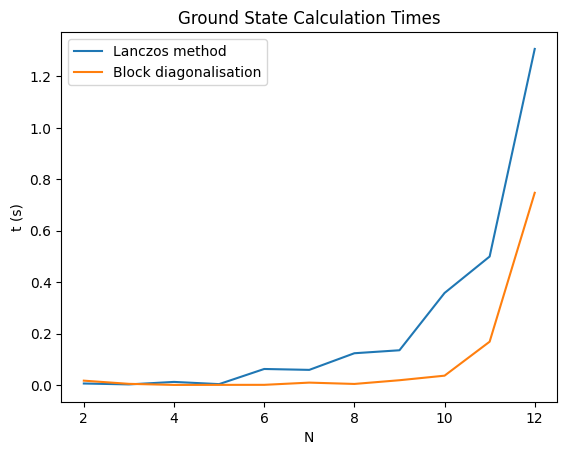

In [ ]:
plt.plot(Ns, Lanczos_times, label='Lanczos method')
plt.plot(Ns, block_diagonalisation_times, label='Block diagonalisation')
# plt.plot(Ns, diag_times, label='Direct diagonalisation')
plt.title('Ground State Calculation Times')
plt.ylabel('t (s)')
plt.xlabel('N')
plt.legend()

##b

In [ ]:
start = 0
all_m_z_bin_state_vecs_10, all_m_z_state_vecs_10 = collect_m_z_state_vecs(basis_vecs_6_12[-3])
all_E = []
lowest_4_E = []

# for j_m_z, m_z_bin_state_vecs in enumerate(all_m_z_bin_state_vecs_10[start:]):
all_f = []
all_f_norms = []
print(len(all_m_z_bin_state_vecs_10[5]))
M = len(all_m_z_state_vecs_10[5])

# f_0
c = (np.random.randn(M))
f = c
all_f.append(f)
norm_f = np.linalg.norm(f)
all_f_norms.append(norm_f)

H_block = construct_H_block(all_m_z_bin_state_vecs_10[5], all_m_z_state_vecs_10[5])
# print(H_block)

all_a = []
all_b = []

H_f = np.dot(H_block,f)
norm_f = np.linalg.norm(f)

# a0
a = np.dot(f, H_f)/norm_f**2
all_a.append(a)

tri_d_H = construct_tri_d_H(1, all_a, all_b)

tri_d_H_evals, tri_d_H_evecs = np.linalg.eigh(tri_d_H)
# lowest_4_E.append(np.sort(tri_d_H_evals)[:4])
all_E.extend(tri_d_H_evals)
# print(f'all_E = {all_E}')
min_E = min(all_E)
# print(f'Min(E) = {min_E}')

#f1
f = H_f - a*f
# print(f'<f_m|f_m-1> = {np.dot(f, all_f[-1])}')
norm_f = np.linalg.norm(f)

all_f.append(f)
all_f_norms.append(norm_f)

# print('Entering the M loop...')
for L in range(1,M):
  H_f = np.dot(H_block,f)
  # a1+
  a = np.dot(f, H_f)/norm_f**2
  all_a.append(a)
  # b0+
  b = (norm_f/all_f_norms[-2])**2
  all_b.append(b)

  tri_d_H = construct_tri_d_H(L+1, all_a, all_b)
  # print(f'Tri-D H:')
  # print(tri_d_H)
  # print(f'all_a = {all_a}')
  # print(f'all_b = {all_b}')

  tri_d_H_evals, tri_d_H_evecs = np.linalg.eigh(tri_d_H)
  # print(f'all_E = {all_E}')
  new_min_E = min(tri_d_H_evals)
  print(f'new_min_E = {new_min_E}')

  if (L > 1):
    print(f'min_E_L = {min_E_L}')
    if abs(new_min_E - min_E_L) < 1e-6:
      print(f'CONVERGENCE CONDITION EXIT: New E_min = {new_min_E}, E_min = {min_E_L}')
      break
    min_E_L = min(min_E_L, new_min_E)
  else:
    min_E_L = new_min_E


  # f2+
  f = H_f - a*f - b*all_f[-2]
  norm_f = np.linalg.norm(f)

  all_f.append(f)
  all_f_norms.append(norm_f)

  H_f = np.dot(H_block, f)
  norm_f = np.linalg.norm(f)

  lowest_4_E.append(np.sort(tri_d_H_evals)[:4])
  print('xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx')

all_E.extend(tri_d_H_evals)
print('---------------------------------------------------------------------')

252
new_min_E = -1.8806936041961029
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
new_min_E = -3.1020420744770356
min_E_L = -1.8806936041961029
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
new_min_E = -3.699578236332991
min_E_L = -3.1020420744770356
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
new_min_E = -4.048790201370738
min_E_L = -3.699578236332991
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
new_min_E = -4.238450045024035
min_E_L = -4.048790201370738
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
new_min_E = -4.345739477071804
min_E_L = -4.238450045024035
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
new_min_E = -4.422943714920775
min_E_L = -4.345739477071804
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
new_min_E = -4.470186314115914
min_E_L = -4.422943714920775
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx

[3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]


Text(0.5, 0, 'Λ')

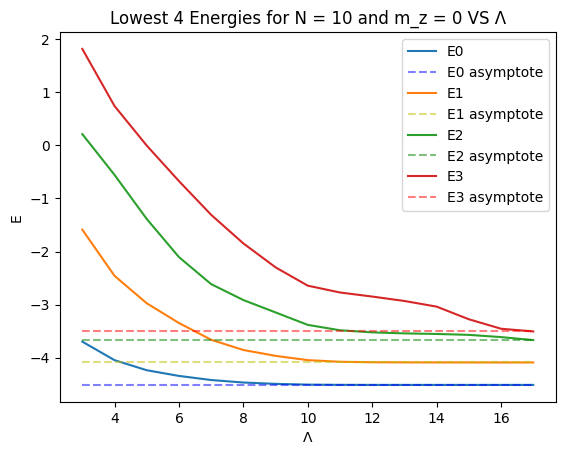

In [ ]:
# print(lowest_4_E[2:])
lowest_4_E_from_L3 = np.array(lowest_4_E[2:])
E1 = lowest_4_E_from_L3[:,0]
E2 = lowest_4_E_from_L3[:,1]
E3 = lowest_4_E_from_L3[:,2]
E4 = lowest_4_E_from_L3[:,3]
# print(E1)

L3 = [l for l in range(3,len(lowest_4_E)+1)]
E_0_asymptote = [E1[-1] for l in L3]
E_1_asymptote = [E2[-1] for l in L3]
E_2_asymptote = [E3[-1] for l in L3]
E_3_asymptote = [E4[-1] for l in L3]
print(L3)
plt.plot(L3, E1, label='E0')
plt.plot(L3, E_0_asymptote, 'b--', label='E0 asymptote', alpha=0.5)

plt.plot(L3, E2, label='E1')
plt.plot(L3, E_1_asymptote, 'y--', label='E1 asymptote', alpha=0.5)

plt.plot(L3, E3, label='E2')
plt.plot(L3, E_2_asymptote, 'g--', label='E2 asymptote', alpha=0.5)

plt.plot(L3, E4, label='E3')
plt.plot(L3, E_3_asymptote, 'r--', label='E3 asymptote', alpha=0.5)

plt.legend()
plt.title('Lowest 4 Energies for N = 10 and m_z = 0 VS Λ')
plt.ylabel('E')
plt.xlabel('Λ')

#Workshop

In [ ]:
import numpy as np

# Assuming you have a NumPy array of bits (0s and 1s)
binary_array = np.array([1, 0, 1, 0, 1])

# Convert the binary array to an integer
decimal_integer = np.packbits(binary_array, None, 'little')

print("Binary Array:", binary_array)
print("Decimal Integer:", decimal_integer)

Binary Array: [1 0 1 0 1]
Decimal Integer: [21]


In [ ]:
np.char.array(np.array([0,1])).tostring().decode('utf-8')

<ipython-input-15-cf470b0f725f>:1: DeprecationWarning: tostring() is deprecated. Use tobytes() instead.
  np.char.array(np.array([0,1])).tostring().decode('utf-8')


'01'

In [ ]:
np.char.array(np.array([0,1])).tobytes().decode('utf-8')

'01'

In [ ]:
np.packbits(np.array([0, 1]) + np.zeros(8).astype(int), None, 'little')

ValueError: operands could not be broadcast together with shapes (2,) (8,) 